In [ ]:
import warnings
from pathlib import Path
from matplotlib import pyplot as plt
import prism
import pandas as pd
import xarray as xr
import numpy as np
import logging
import pickle 


from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
    SharesInflowStocks,
    RestOf
)
from imagematerials.preprocessing import get_preprocessing_data
from imagematerials.rest_of import rest_of_preprocessing
from imagematerials.util import reindex_material

In [2]:
# Define the complete timeline, including historic tail

YEAR_START  = 1971    # start year of the simulation period
YEAR_END    = 2100    # end year of the calculations
YEAR_OUT    = 2100    # year of output generation = last year of reporting
time_start = 1971
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_OUT, 1)


# Define the scenario list
scenario_list = {
#               ----scen_id----             ----climate_scenario----            ----circular_economy_scenario----   
                "base":                     ("SSP2",                            ["base"]),
                "narrow_product":           ("SSP2_narrow_prod",                ["base", "narrow_product"]),
                "narrow_activity":          ("SSP2_narrow_act",                 ["base", "narrow_activity"]),
                "narrow":                   ("SSP2_narrow",                     ["base", "narrow_product", "narrow_activity"]),
                "slow":                     ("SSP2_slow",                       ["base", "slow"]),
                "close":                    ("SSP2_close",                      ["base", "close"]),
                "narrow_slow_close":        ("SSP2_narrow_slow_close",          ["base", "narrow_product", "narrow_activity","slow","close"]),

                "base_26":                  ("SSP2_26_tax",                     ["base"]),
                "narrow_product_26":        ("SSP2_narrow_prod_26_tax",         ["base", "narrow_product"]),
                "narrow_activity_26":       ("SSP2_narrow_act_26_tax",          ["base", "narrow_activity"]),
                "narrow_26":                ("SSP2_narrow_26_tax",              ["base", "narrow_product", "narrow_activity"]),
                "slow_26":                  ("SSP2_slow_26_tax",                ["base", "slow"]),
                "close_26":                 ("SSP2_close_26_tax",               ["base", "close"]),
                "narrow_slow_close_26":     ("SSP2_narrow_slow_close_26_tax",   ["base", "narrow_product", "narrow_activity","slow","close"]),

                "base_19":                  ("SSP2_19_tax", ["base"]),
                "narrow_slow_close_19":     ("SSP2_narrow_slow_close_19_tax",   ["base", "narrow_product", "narrow_activity","slow","close"]),
                }

# Define paths
scenario_base_path = Path("..", "data", "raw")
CP_scenario_path = Path("..","..","data","IMAGE_CircoMod")

CE_scenario_path = scenario_base_path / 'circular_economy_scenarios'

# define materials list so that arrays have consistent order
# IF A NEW MATERIAL SHOULD BE ADDED HERE, add it also in imagematerials.eol.preprocessing
materials = [
    'aluminium', 'brick', 'cement', 'cobalt', 'concrete', 'copper', 'glass',        
    'lead', 'lithium', 'manganese', 'neodymium', 'nickel', 'plastics',
    'rubber', 'steel', 'tantalum', 'titanium', 'wood'
]

In [3]:
# Loop over scenarios
for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    print(f"Running scenario: {climate_scen} from {CP_scenario_path}")
    print(f"Circular economy scenario: {circular_scen}")
    climate_policy_scenario_dir = CP_scenario_path / climate_scen           # path to climate policy scenario data (i.e., from IMAGE)
    circular_economy_scenario_dirs = {
        scenario: CE_scenario_path / scenario for scenario in circular_scen # path to circular economy scenario data
    }    
    # #REST OF
    rest_sector = rest_of_preprocessing(scenario_base_path, climate_policy_scenario_dir,scenario = climate_scen) #TODO: add this to get_preprocessing_data function
    rest_sector = Sector(name='rest_of', data = rest_sector) # make it a Sector object!


Running scenario: SSP2 from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base']
Running scenario: SSP2_narrow_prod from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base', 'narrow_product']
Running scenario: SSP2_narrow_act from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base', 'narrow_activity']
Using Gompertz coefficients for resource efficiency measures
Running scenario: SSP2_narrow from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base', 'narrow_product', 'narrow_activity']
Using Gompertz coefficients for resource efficiency measures
Running scenario: SSP2_slow from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base', 'slow']
Running scenario: SSP2_close from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base', 'close']
Running scenario: SSP2_narrow_slow_close from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base', 'narrow_product', 'narrow_activity', 'slow', 'close']
Using Gompertz coefficients for resource eff

In [4]:
# Run simulations for all scenarios

all_output = {} # to store outputs for all scenarios

# add debugging statements
logging.basicConfig(
    level=logging.DEBUG,
    format='%(name)s - %(levelname)s - %(message)s',
    force=True  # Override any existing config
)

# Loop over scenarios
for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    print(f"Running scenario: {climate_scen} from {CP_scenario_path}")
    print(f"Circular economy scenario: {circular_scen}")
    climate_policy_scenario_dir = CP_scenario_path / climate_scen           # path to climate policy scenario data (i.e., from IMAGE)
    circular_economy_scenario_dirs = {
        scenario: CE_scenario_path / scenario for scenario in circular_scen # path to circular economy scenario data
    }

# Get preprocessing data for all sectors and adjust material indices
    
    # BUILDINGS
    bld_sector = get_preprocessing_data("buildings", scenario_base_path, climate_policy_scenario_dir, circular_economy_scenario_dirs)

    #VEHICLES
    vhc_sector = get_preprocessing_data("vehicles", scenario_base_path, climate_policy_scenario_dir, circular_economy_scenario_dirs)

    # #ELECTRICITY
    elc_sector = get_preprocessing_data("electricity", scenario_base_path, climate_policy_scenario_dir, circular_economy_scenario_dirs, cache = False)
    elc_gen, elc_grid_lines, elc_grid_add, elc_stor_phs, elc_stor_other = (
    {sec.name: sec for sec in elc_sector}[k]
    for k in ["elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs", "elc_stor_other"])
    
    # END OF LIFE
    eol_sector = get_preprocessing_data("eol", scenario_base_path, circular_economy_scenario_dirs)
    
    # #REST OF
    rest_sector = rest_of_preprocessing(scenario_base_path, climate_policy_scenario_dir,scenario = climate_scen) #TODO: add this to get_preprocessing_data function
    rest_sector = Sector(name='rest_of', data = rest_sector) # make it a Sector object!

    # Reindex materials in all sectors to ensure consistency
    for sec in [
    elc_gen,
    elc_grid_lines,
    elc_grid_add,
    elc_stor_phs,
    elc_stor_other,
    bld_sector,
    vhc_sector,
    eol_sector,
    rest_sector,
]:
        for key, val in sec.prep_data.items():
            sec.prep_data[key] = reindex_material(val, materials)

# Build and run the model
    factory = ModelFactory(
    [bld_sector, vhc_sector,
    *elc_sector,                # *: unpacks electricity sectors 
    eol_sector, 
    rest_sector,
    ],complete_timeline 
    ).add(GenericStocks, ["buildings", 
                          "vehicles", 
                          "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs"
                          ]
    ).add(SharesInflowStocks, ["elc_stor_other"]
    ).add(GenericMaterials,  "vehicles"
    ).add(MaterialIntensities, ["buildings",
                        "elc_gen", "elc_grid_lines","elc_grid_add","elc_stor_phs","elc_stor_other"
                        ]
    ).add(Maintenance, "vehicles"
    ).add(RestOf, "rest_of", input_sources={
       "gompertz_coefs": "rest_of",
        "gdp_per_capita": "rest_of",
        "population": "rest_of",
        "historic_diff_consumption_mean": "rest_of",
        "historic_diff_consumption_total": "rest_of"
}                  
    ).add(EndOfLife, "eol", input_sources={
    "outflow_by_cohort_materials": ["vehicles", "buildings",
                                    "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs"
                                    ],
    "inflow_materials":  ["vehicles", "buildings",
                          "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs"
                         ],
    "collection": "eol",
    "reuse": "eol",
    "recycling": "eol"}
)
    model = factory.finish() # create the model
    
    # Run the simulation (suppressing warnings)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline) 

     # save relevant outputs only to reduce memory usage
    all_output[scen_id] = {
        # MATERIAL inflows
        "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"], 
                             model.elc_gen["inflow_materials"], model.elc_grid_lines["inflow_materials"], model.elc_grid_add["inflow_materials"], model.elc_stor_phs["inflow_materials"], model.elc_stor_other["inflow_materials"], 
                             model.rest_of["inflow_materials"]],
        # MATERIAL stocks
        "stock_by_cohort_materials": [model.vehicles["stock_by_cohort_materials"], model.buildings["stock_by_cohort_materials"], 
                             model.elc_gen["stock_by_cohort_materials"], model.elc_grid_lines["stock_by_cohort_materials"], model.elc_grid_add["stock_by_cohort_materials"], model.elc_stor_phs["stock_by_cohort_materials"], model.elc_stor_other["stock_by_cohort_materials"]], 
        # MATERIAL outflows
        "outflow_by_cohort_materials": [model.vehicles["outflow_by_cohort_materials"], model.buildings["outflow_by_cohort_materials"],
            model.elc_gen["outflow_by_cohort_materials"], model.elc_grid_lines["outflow_by_cohort_materials"], model.elc_grid_add["outflow_by_cohort_materials"], model.elc_stor_phs["outflow_by_cohort_materials"], model.elc_stor_other["outflow_by_cohort_materials"]
            ],
        # PRODUCT inflows
        "inflow": [
            model.vehicles["inflow"], model.buildings["inflow"],
            model.elc_gen["inflow"], model.elc_grid_lines["inflow"], model.elc_grid_add["inflow"], model.elc_stor_phs["inflow"], model.elc_stor_other["inflow"]
            ],
        # PRODUCT stocks
        "stocks": [
            model.vehicles["stocks"],model.buildings["stocks"],
            model.elc_gen["stocks"], model.elc_grid_lines["stocks"], model.elc_grid_add["stocks"], model.elc_stor_phs["stocks"], model.elc_stor_other["stocks"]
            ],
        # PRODUCT outflows
        "outflow": [
            model.vehicles["stocks"], 
            model.buildings["stocks"],
            model.elc_gen["stocks"],model.elc_grid_lines["stocks"],model.elc_grid_add["stocks"],model.elc_stor_phs["stocks"],model.elc_stor_other["stocks"]
            ],
        # EoL materials
        "sum_outflow": model.eol["sum_outflow"],
        "reusable_materials": model.eol["reusable_materials"],
        "recyclable_materials": model.eol["recyclable_materials"]
    }
    print(f"Finished {scen_id}")

Running scenario: SSP2 from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base']


root - DEBUG - implemented 'base' for Commercial Buildings


FUNCTION CALLED
ce keys: ['base']
ce_scen = None


root - DEBUG - implemented 'base' for Residential Buildings
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env2\Lib\site-packages\xarray\core\indexing.py:1720: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


CE config: []
Finished base
Running scenario: SSP2_narrow_prod from ..\..\data\IMAGE_CircoMod
Circular economy scenario: ['base', 'narrow_product']


...

FUNCTION CALLED
ce keys: ['base', 'narrow_product', 'narrow_activity', 'slow', 'close']
ce_scen = None
mode = relative


c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env2\Lib\site-packages\numpy\lib\_function_base_impl.py:2616: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env2\Lib\site-packages\numpy\lib\_function_base_impl.py:2616: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env2\Lib\site-packages\numpy\lib\_function_base_impl.py:2616: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\Users\Zanon004\AppData\Local\miniforge3\envs\mat-env2\Lib\site-packages\numpy\lib\_function_base_impl.py:2616: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  args = tuple(asanyarray(arg) for arg in args)
c:\U

implemented 'slow' for Buildings


root - DEBUG - implemented 'narrow_product' for Commercial Buildings (lightweighting)
root - DEBUG - implemented 'narrow_product' for Residential Buildings (lightweighting)
root - DEBUG - implemented 'slow' for Vehicles (extend lifetimes)
root - DEBUG - implemented 'narrow_product' for Vehicles (mileage/kilometrage increase)
root - DEBUG - implemented 'narrow_product' for Vehicles (lightweighting)


narrow|lightweighting applied to  GenerationMaterialIntensities
slow|lifetime increase applied to  GenerationLifetime
narrow|lightweighting applied to  GridMaterialIntensitiesAdditions
slow|lifetime increase applied to  GridLifetime
CE config: []
Using Gompertz coefficients for resource efficiency measures
Finished narrow_slow_close_19


In [5]:
# pickle your run
outdir = Path("..", "data", "output")
outdir.mkdir(parents=True, exist_ok=True)

pkl_path = outdir / "ALL_OUTPUT_ALL_SCENARIOS_14-4-26.pkl"

with open(pkl_path, "wb") as f:
    pickle.dump(all_output, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved to:", pkl_path)


Saved to: ..\data\output\ALL_OUTPUT_ALL_SCENARIOS_14-4-26.pkl


matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=8.0.


matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\Zanon004\\AppData\\Local\\miniforge3\\envs\\mat-env2\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\Zanon004\\AppData\\Local\\miniforge3\\envs\\mat-env2\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\Zanon004\\AppData\\Local\\miniforge3\\envs\\mat-env2\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='c

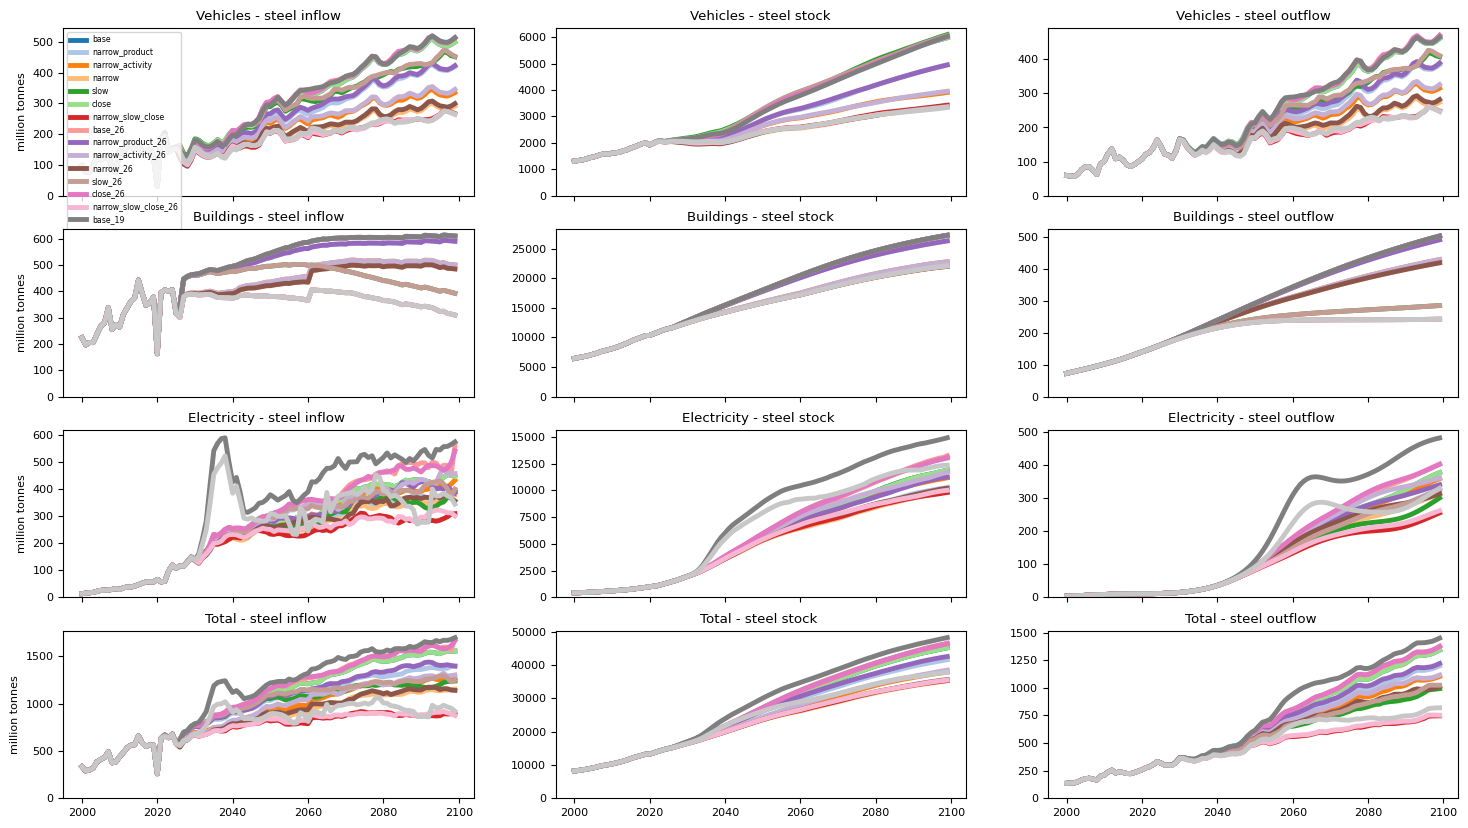

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
region = "World" # "World" OR region code (e.g., "CHN", "BRA"...)
t0 = 2000
linewidth = 3.5 
alpha=1
material = "steel"
fig, axes = plt.subplots(4, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()   # flatten 2D array of axes to 1D for easier indexing


colors = sns.color_palette("tab20")
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

# --- Vehicles - steel inflow ---
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][0].to_array().sel(time=range(t0, 2100))
    time = inflow.coords["time"]
    if region == "World":
        axes[0].plot(time, inflow.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[0].plot(time, inflow.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[0].set_title(f"Vehicles - {material} inflow")
axes[0].set_ylabel("million tonnes")
axes[0].set_ylim(bottom=0)

# --- Vehicles - steel stock ---
for scen_id, output in all_output.items():
    stock = output["stock_by_cohort_materials"][0].sel(Time=range(t0, 2100))
    Time = stock.coords["Time"]
    if region == "World":
        axes[1].plot(Time, stock.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[1].plot(Time, stock.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[1].set_title(f"Vehicles - {material} stock")
axes[1].set_ylim(bottom=0)

# --- Vehicles - steel outflow ---
for scen_id, output in all_output.items():
    outflow = output["outflow_by_cohort_materials"][0].to_array().sel(time=range(t0, 2100))
    time = outflow.coords["time"]
    if region == "World":
        axes[2].plot(time, outflow.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[2].plot(time, outflow.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[2].set_title(f"Vehicles - {material} outflow")
axes[2].set_ylim(bottom=0)

# --- Buildings - steel inflow ---
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][1].to_array().sel(time=range(t0, 2100))
    time = inflow.coords["time"]
    if region == "World":
        axes[3].plot(time, inflow.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[3].plot(time, inflow.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[3].set_title(f"Buildings - {material} inflow")
axes[3].set_ylabel("million tonnes")
axes[3].set_ylim(bottom=0)

# --- Buildings - steel stock ---
for scen_id, output in all_output.items():
    stock = output["stock_by_cohort_materials"][1].sel(Time=range(t0, 2100))
    Time = stock.coords["Time"]
    if region == "World":
        axes[4].plot(Time, stock.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[4].plot(Time, stock.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[4].set_title(f"Buildings - {material} stock")
axes[4].set_ylim(bottom=0)

# --- Buildings - steel outflow ---
for scen_id, output in all_output.items():
    outflow = output["outflow_by_cohort_materials"][1].to_array().sel(time=range(t0, 2100))
    time = outflow.coords["time"]
    if region == "World":
        axes[5].plot(time, outflow.sel(material=material).sum("Type").sum("Region") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
    else:
        axes[5].plot(time, outflow.sel(material=material, Region = region ).sum("Type") / 1e9, label=scen_id,linewidth = linewidth,alpha=alpha)
axes[5].set_title(f"Buildings - {material} outflow")
axes[5].set_ylim(bottom=0)

elec_idxs = [2, 3, 4, 5, 6]  # sectors elc_gen, elc_grid_lines, elc_grid_add, elc_stor_phs, elc_stor_other

# --- Electricity - steel inflow ---
for scen_id, output in all_output.items():
    if region == "World":
        inflows = [
                output["inflow_materials"][i].to_array().sel(time=range(t0, 2100)).sum("Region")
                for i in elec_idxs
            ]
        inflow_elec = xr.concat(inflows, dim="subsector").sum("subsector")  # aggregate sectors 2–6
        time = inflow_elec.coords["time"]
    else:
        inflows = [
            output["inflow_materials"][i].to_array().sel(time=range(t0, 2100), Region=region)
            for i in elec_idxs
        ]
        inflow_elec = xr.concat(inflows, dim="subsector").sum("subsector")  # aggregate sectors 2–6
        time = inflow_elec.coords["time"]

    axes[6].plot(
        time,
        inflow_elec.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[6].set_title(f"Electricity - {material} inflow ")
axes[6].set_ylabel("million tonnes")
axes[6].set_ylim(bottom=0)

# --- Electricity - steel stock ---
for scen_id, output in all_output.items():
    if region == "World":
        stocks = [
            output["stock_by_cohort_materials"][i].sel(Time=range(t0, 2100)).sum("Region")
            for i in elec_idxs
        ]
        stock_elec = xr.concat(stocks, dim="subsector").sum("subsector")
        Time = stock_elec.coords["Time"]
    else:
        stocks = [
            output["stock_by_cohort_materials"][i].sel(Time=range(t0, 2100), Region=region)
            for i in elec_idxs
        ]
        stock_elec = xr.concat(stocks, dim="subsector").sum("subsector")
        Time = stock_elec.coords["Time"]

    axes[7].plot(
        Time,
        stock_elec.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[7].set_title(f"Electricity - {material} stock ")
axes[7].set_ylim(bottom=0)


# --- Electricity - steel outflow ---
for scen_id, output in all_output.items():
    if region == "World":
        outflows = [
            output["outflow_by_cohort_materials"][i].to_array().sel(time=range(t0, 2100)).sum("Region")
            for i in elec_idxs
        ]
        outflow_elec = xr.concat(outflows, dim="subsector").sum("subsector")
        time = outflow_elec.coords["time"]
    else:
        outflows = [
            output["outflow_by_cohort_materials"][i].to_array().sel(time=range(t0, 2100), Region=region)
            for i in elec_idxs
        ]
        outflow_elec = xr.concat(outflows, dim="subsector").sum("subsector")
        time = outflow_elec.coords["time"]

    axes[8].plot(
        time,
        outflow_elec.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[8].set_title(f"Electricity - {material} outflow ")
axes[8].set_ylim(bottom=0)


total_idxs = [0, 1, 2, 3, 4, 5, 6]

# --- Total - steel inflow  ---
for scen_id, output in all_output.items():
    if region == "World":
        inflows = [
            output["inflow_materials"][i].to_array().sel(time=range(t0, 2100)).sum("Region")
            for i in total_idxs
        ]
        inflow_total = xr.concat(inflows, dim="subsector").sum("subsector")  
        time = inflow_total.coords["time"]
    else:
        inflows = [
            output["inflow_materials"][i].to_array().sel(time=range(t0, 2100), Region=region)
            for i in total_idxs
        ]
        inflow_total = xr.concat(inflows, dim="subsector").sum("subsector")  
        time = inflow_total.coords["time"]
    axes[9].plot(
        time,
        inflow_total.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[9].set_title(f"Total - {material} inflow ")
axes[9].set_ylabel("million tonnes")
axes[9].set_ylim(bottom=0)


# --- Total - steel stock ---
for scen_id, output in all_output.items():
    if region == "World":
        stocks = [
            output["stock_by_cohort_materials"][i].sel(Time=range(t0, 2100)).sum("Region")
            for i in total_idxs
        ]
        stock_total = xr.concat(stocks, dim="subsector").sum("subsector")
        Time = stock_total.coords["Time"]
    else:   
        stocks = [
            output["stock_by_cohort_materials"][i].sel(Time=range(t0, 2100), Region = region)
            for i in total_idxs
        ]
        stock_total = xr.concat(stocks, dim="subsector").sum("subsector")
        Time = stock_total.coords["Time"]
    axes[10].plot(
        Time,
        stock_total.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[10].set_title(f"Total - {material} stock ")
axes[10].set_ylim(bottom=0)


# --- Total - steel outflow ---
for scen_id, output in all_output.items():
    if region == "World":
        outflows = [
            output["outflow_by_cohort_materials"][i].to_array().sel(time=range(t0, 2100)).sum("Region")
            for i in total_idxs
        ]
        outflow_total = xr.concat(outflows, dim="subsector").sum("subsector")
        time = outflow_total.coords["time"]
    else:
        outflows = [
            output["outflow_by_cohort_materials"][i].to_array().sel(time=range(t0, 2100), Region=region)
            for i in total_idxs
        ]
        outflow_total = xr.concat(outflows, dim="subsector").sum("subsector")
        time = outflow_total.coords["time"]

    axes[11].plot(
        time,
        outflow_total.sel(material=material).sum("Type") / 1e9,
        label=scen_id,
        linewidth=linewidth,
        alpha=alpha,
    )
axes[11].set_title(f"Total - {material} outflow ")

axes[11].set_ylim(bottom=0)


# Legend and layout
axes[0].legend(loc="upper left", fontsize='x-small')
plt.rcParams.update({'font.size': 8})


#plt.tight_layout()
plt.show()

In [11]:
merged = all_output

outdir = Path("..", "data", "output", "TIMER_input")
xlsx_path = outdir / "IMAGE_materials_export_ALLAPRIL26.xlsx"

# ============================================================
# Helpers
# ============================================================
materials = [
    'aluminium', 'brick', 'concrete', 'cement', 'cobalt', 'copper', 'glass',
    'lead', 'lithium', 'manganese', 'neodymium', 'nickel', 'plastics',
    'rubber', 'steel', 'tantalum', 'titanium', 'wood'
]

def normalize_time(da):
    """
    Ensure the time dimension is always called 'time'.
    This avoids headaches later when combining arrays.
    """
    if "Time" in da.dims:
        da = da.rename({"Time": "time"})
    return da

def to_Mt_plain(da):
    """
    Convert a pint-xarray DataArray to Mt (megatonnes) as plain float values.
    Works for kg, metric_ton, etc., as long as pint can convert to kilogram.
    """
    da_kg = da.pint.to("kilogram")          # convert units properly
    da_plain = da_kg.pint.dequantify()      # strip pint Quantity -> numpy floats
    return da_plain * 1e-9                  # kg -> Mt


def export_long(da, *, variable, material, sector, subsector, unit):
    """
    Long format:
    scenario | Region | time | value | material | variable | unit | sector | subsector
    """
    df = da.to_dataframe(name="value").reset_index()

    df["variable"] = variable
    df["material"] = material
    df["sector"] = sector
    df["subsector"] = subsector
    df["unit"] = unit

    # Optional: keep a consistent column order
    cols = ["scenario", "Region", "time", "material", "variable", "unit", "sector", "subsector", "value"]
    df = df[cols]

    return df


# ============================================================
# 1. Collect the data required in IMAGE 
# ============================================================


scenarios = list(merged.keys())

inflow_list = []
reusable_list = []
recyclable_list = []

with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
    for scen in scenarios:
        out = merged[scen]

        # ---------- inflow_materials ----------
        inflow_sec = []

        for i, sec in enumerate([
            "vehicles", "buildings",
            "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs", "elc_stor_other"
        ]):
            da = normalize_time(out["inflow_materials"][i].to_array())
            da = to_Mt_plain(da)
            da = da.fillna(0.0)

            # sum over Type -> total inflow per sector
            if "Type" in da.dims:
                da = da.sum("Type")

            da = da.reindex(material=materials, fill_value=0.0)
            da = da.expand_dims(sector=[sec])
           
            inflow_sec.append(da)

        # rest_of sector
        da_rest = normalize_time(out["inflow_materials"][7])
        da_rest = to_Mt_plain(da_rest)
        da_rest = da_rest.reindex(material=materials, fill_value=0.0)
        da_rest = da_rest.fillna(0.0)
        da_rest = da_rest.expand_dims(sector=["rest_of"])
        
        inflow_sec.append(da_rest)

        # combine all sectors
        inflow = xr.concat(inflow_sec, dim="sector")

        # add scenario dimension
        inflow = inflow.expand_dims(scenario=[scen])
        inflow_list.append(inflow)

        # ---------- reusable_materials (EoL) ----------
        da_reuse = normalize_time(out["reusable_materials"].to_array())

        if "Type" in da_reuse.dims:
            da_reuse = da_reuse.sum("Type")
        da_reuse = da_reuse.reindex(material=materials, fill_value=0.0)
        da_reuse = da_reuse.expand_dims(scenario=[scen])
        da_reuse = to_Mt_plain(da_reuse).fillna(0.0)
        reusable_list.append(da_reuse)

        # ---------- recyclable_materials (EoL, KEEP Type) ----------
        da_recycle = normalize_time(out["recyclable_materials"].to_array())
        da_recycle = da_recycle.reindex(material=materials, fill_value=0.0)
        da_recycle = da_recycle.expand_dims(scenario=[scen])
        da_recycle = to_Mt_plain(da_recycle).fillna(0.0)
        recyclable_list.append(da_recycle)


    # Stack all scenarios together
    inflow = xr.concat(inflow_list, dim="scenario")
    reusable = xr.concat(reusable_list, dim="scenario")
    recyclable = xr.concat(recyclable_list, dim="scenario")


    # ============================================================
    # 2. Calculate ExoDemand  for steel and cement
    # ============================================================

    cement_in_concrete_ratio = 0.12

    # Calculating total cement inflow (direct + from concrete) and reusable
    direct_cement = inflow.sel(material="cement", sector = "rest_of")
    concrete = (
        inflow
        .sel(material="concrete", sector=["buildings", "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs", "elc_stor_other"])
        .sum("sector")
    )
    reusable_concrete = reusable.sel(material="concrete")
    reusable_concrete = reusable_concrete.reindex_like(concrete, fill_value = 0.0)

    net_concrete = (concrete - reusable_concrete).clip(min = 0).expand_dims(material = ["cement"])
    cement_from_concrete = net_concrete * cement_in_concrete_ratio

    direct_cement, cement_from_concrete = xr.align(direct_cement, cement_from_concrete, join="outer", fill_value=0.0)
    exo_cement = (direct_cement + cement_from_concrete).fillna(0.0)

    # Select steel inflow and reusable
    inflow_steel = inflow.sel(material="steel", sector=["buildings", "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs", "elc_stor_other"]).sum("sector")
    inflow_steel_rest = inflow. sel(material = "steel", sector = "rest_of")
    total_inflow_steel = inflow_steel + inflow_steel_rest
    total_inflow_steel = total_inflow_steel.fillna(0.0)
    reusable_steel = reusable.sel(material="steel").reindex_like(total_inflow_steel, fill_value=0.0).fillna(0.0)

    exo_steel = (total_inflow_steel - reusable_steel).clip(min=0).fillna(0.0)
  
    # concat both exo_demands
    exo = xr.concat([exo_steel, exo_cement], dim="material")

    for mat in ["steel", "cement"]:
        da = exo.sel(material=mat)

        df = export_long(
            da,
            variable="ExoDemand",
            material=mat,
            sector="image_input",
            subsector="Total",
            unit="Mt",
        )

        df.to_excel(
        writer,
        sheet_name=f"ExoDemand_{mat}",
        index=False,
    )

    # ============================================================
    # 3. Other materials vs base
    # ============================================================

    # Exclude cement, concrete, steel
    other = inflow.sel(
        material=~inflow.material.isin(["cement", "concrete", "steel"])
    )

    # Sum over materials and sectors
    other_total = other.sum(["material", "sector"])

    # Split base vs other scenarios
    base = other_total.sel(scenario="base")

    ratio_all = other_total / base
    ratio_all = ratio_all.drop_sel(scenario="base")

    df = export_long(
        ratio_all,
        variable="MatReduction",
        material="ALL_EXCL_CEMENT_CONCRETE_STEEL",
        sector="image_input",
        subsector="Total",
        unit="ratio",
    )    

    df.to_excel(
            writer,
            sheet_name="MatReduction_vs_base",
            index=False,
        )

    # ============================================================
    # 4. EoL recyclable by subsector (Type)
    # ============================================================

    # Keep Type dimension → subsector
    recyclable_sc = recyclable.sel(material=["steel", "concrete"])

    for mat in ["steel", "concrete"]:
        da = recyclable_sc.sel(material=mat).rename({"Type": "subsector"})

        df = da.to_dataframe(name="value").reset_index()
        df["material"] = mat
        df["variable"] = "recyclable_materials"
        df["sector"] = "eol"
        df["unit"] = "Mt"

        cols = ["scenario", "Region", "time", "material", "variable", "unit", "sector", "subsector", "value"]
        df = df[cols]

        df.to_excel(writer, sheet_name=f"EoL_recyclable_{mat}", index=False)
